## Part 1 — Counterfactual forecaster

Train a GNN over the POI catchment/spatial graph on **clean, non-game node-hours** (`clean_control == True`, i.e. not a Giants home-game day and not another ballpark event day) to predict `visitor_hours` from graph structure + calendar

+ weather alone. Because this first model never sees game flags, running it on game hours yields a counterfactual "what foot traffic would have looked like with no game." Thus, we can use `lift = observed - predicted` on those hours as the causal signal we feed into Part 2.

#### - Design
2-layer GCN encoder (using the spatial-distance / catchment-similarity edge weights directly) turns static node attributes (ring, distance to park, category, lat/lon) into a structural embedding per POI — computed once per forward pass, since it doesn't depend on the hour. A shared MLP head then combines that embedding with per-hour  calendar/weather features to predict `log1p(visitor_hours)` for every node at every hour in a batch. This avoids rebuilding a graph per timestep while still routing spatial information through learned, weighted message passing.

In [ ]:
"""Imports and initial seeding"""

import numpy as np
import torch
import polars as pl
import torch.nn as nn
import torch.nn.functional as F

from matplotlib import pyplot as plt
from pathlib import Path
from torch_geometric.nn import GCNConv

RNG_SEED = 0
torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

/home/poppop/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

In [ ]:
"""Quick ummary view into each gold level .parquet file as saved locally"""

data_path = Path().cwd().parent / "data"
for file_name in data_path.glob("*.parquet"):
	df = pl.read_parquet(data_path / file_name)
	print(file_name.parts[-1], df.shape)
	print(df.columns)
	print(df.dtypes)
	print()

event_study_ring.parquet (120, 9)
['ring_id', 'ring', 'measure', 'slice', 'n_games', 'mean_lift', 'se_lift', 'mean_lift_pct', 'se_lift_pct']
[Int64, String, String, String, Int64, Float64, Float64, Float64, Float64]

distance_decay.parquet (20, 9)
['ring_id', 'ring', 'measure', 'ring_mid_m', 'n_games', 'mean_lift', 'se_lift', 'mean_lift_pct', 'se_lift_pct']
[Int64, String, String, Int32, Int64, Float64, Float64, Float64, Float64]

gnn_time_hour.parquet (26280, 27)
['date', 'hour', 'ts', 'giants_home', 'n_games', 'first_pitch_hour', 'day_night', 'clean_control', 'dow', 'month', 'relative_hour', 'ballpark_day', 'chase_day', 'moscone_day', 'citywide_day', 'street_fair_day', 'us_federal_holiday', 'tmax', 'tmin', 'tavg', 'prcp', 'awnd', 'temp_hr', 'prcp_hr', 'wind_hr', 'chase_event_hour', 'split']
[Date, Int16, Datetime(time_unit='us', time_zone=None), Boolean, Int64, Int64, String, Boolean, Int64, Int64, Int32, Boolean, Boolean, Boolean, Boolean, Boolean, Boolean, Int64, Int64, String, Flo

In [5]:
"""Load the tables needed for the GNN.

Node attributes, both edge sets, the hourly calendar/weather spine, the node-hour
target, and the game-level covariate/lift table will all be used to build Part 2's 
training set later on.
"""

nodes_raw = pl.read_parquet(data_path / "gnn_nodes.parquet")
edges_spatial_raw = pl.read_parquet(data_path / "gnn_edges_spatial.parquet")
edges_catchment_raw = pl.read_parquet(data_path / "gnn_edges_catchment.parquet")
time_hour = pl.read_parquet(data_path / "gnn_time_hour.parquet").sort("ts")
target_raw = pl.read_parquet(data_path / "gnn_target_node_hour.parquet")
game_labels = pl.read_parquet(data_path / "gnn_game_labels.parquet")

print("clean_control == all(NOT (giants_home OR ballpark_day)):",
	  (time_hour["clean_control"] == ~(time_hour["giants_home"] | time_hour["ballpark_day"])).all())

clean_control == all(NOT (giants_home OR ballpark_day)): True


In [ ]:
"""Create Static Node map.

Only `hourly_complete` nodes have a reliable enough hourly series to train
and evaluate a forecaster on (1,264 of 5,842 POIs). 

The single `is_venue` node in that set is the ballpark itself -- it stays 
in the graph so its neighbors can message-pass off of it, but it is excluded
from the prediction loss since "spillover to nearby POIs" is what we're modeling,
not attendance at the park.
"""

nodes = (
	nodes_raw
	.filter(pl.col("hourly_complete"))
	.with_columns(pl.col("footprint_id").cast(pl.Int64))
	.with_row_index("node_idx")
)
n_nodes = nodes.height
node_id_to_idx = dict(zip(nodes["footprint_id"].to_list(), nodes["node_idx"].to_list()))
venue_node_idx = nodes.filter(pl.col("is_venue"))["node_idx"].to_list()
print(f"n_nodes = {n_nodes}, venue_node_idx = {venue_node_idx}")

# --- categorical: top_category -> embedding index ---
categories = nodes["top_category"].fill_null("UNKNOWN").unique().sort().to_list()
cat_to_idx = {c: i for i, c in enumerate(categories)}
n_categories = len(categories)
node_category_idx = torch.tensor(
	[cat_to_idx[c] for c in nodes["top_category"].fill_null("UNKNOWN").to_list()],
	dtype=torch.long,
)

# --- continuous / one-hot static features ---
def zscore(s: pl.Series) -> pl.Series:
	return (s - s.mean()) / s.std()

ring_onehot = nodes.select(pl.col("ring_id")).to_dummies("ring_id")
static_df = pl.concat(
	[
		ring_onehot,
		nodes.select(
			zscore(pl.col("dist_m")).alias("dist_m_z"),
			zscore(pl.col("lat")).alias("lat_z"),
			zscore(pl.col("lon")).alias("lon_z"),
			pl.col("is_venue").fill_null(False).cast(pl.Float32).alias("is_venue"),
		),
	],
	how="horizontal",
)
node_static_x = torch.tensor(static_df.to_numpy(), dtype=torch.float32)
static_feat_names = static_df.columns
print("static feature dims:", node_static_x.shape, static_feat_names)

n_nodes = 1264, venue_node_idx = [51]
static feature dims: torch.Size([1264, 8]) ['ring_id_1', 'ring_id_2', 'ring_id_3', 'ring_id_4', 'dist_m_z', 'lat_z', 'lon_z', 'is_venue']


In [ ]:
"""Build out graph edges.

Union the spatial (k-NN by distance) and catchment
(cosine similarity of visitor overlap) edge sets, restricted to the
hourly_complete node subset, into a single undirected weighted graph.

Where both edge sets connect a pair, average their (already 0-1) weights;
where only one does, use that one.
"""

node_lookup = nodes.select(["footprint_id", "node_idx"])

def to_lo_hi(df: pl.DataFrame, weight_expr: pl.Expr, weight_name: str) -> pl.DataFrame:
	return (
		df.with_columns(pl.col("a").cast(pl.Int64), pl.col("b").cast(pl.Int64))
		.join(node_lookup.rename({"footprint_id": "a", "node_idx": "u"}), on="a", how="inner")
		.join(node_lookup.rename({"footprint_id": "b", "node_idx": "v"}), on="b", how="inner")
		.with_columns(weight_expr.alias(weight_name))
		.select(pl.min_horizontal("u", "v").alias("lo"), pl.max_horizontal("u", "v").alias("hi"), weight_name)
	)

spatial_edges = to_lo_hi(edges_spatial_raw, 1.0 / (1.0 + pl.col("edge_dist_m") / 1000.0), "spatial_w")
catchment_edges = to_lo_hi(edges_catchment_raw, pl.col("cos_sim"), "catchment_w")

combined_edges = (
	spatial_edges
	.join(catchment_edges, on=["lo", "hi"], how="full", coalesce=True)
	.unique(subset=["lo", "hi"])
	.filter(pl.col("lo") != pl.col("hi"))
	.with_columns(pl.mean_horizontal(["spatial_w", "catchment_w"]).alias("edge_weight"))
)
print(f"combined undirected edges: {combined_edges.height}")

lo = combined_edges["lo"].to_numpy()
hi = combined_edges["hi"].to_numpy()
w = combined_edges["edge_weight"].to_numpy()

# symmetrize: message passing needs both directions
edge_index = torch.tensor(
	np.stack([np.concatenate([lo, hi]), np.concatenate([hi, lo])]), dtype=torch.long
)
edge_weight = torch.tensor(np.concatenate([w, w]), dtype=torch.float32)
print("edge_index:", edge_index.shape, "edge_weight:", edge_weight.shape)

combined undirected edges: 9675
edge_index: torch.Size([2, 19350]) edge_weight: torch.Size([19350])


In [ ]:
"""Per-hour calendar + weather features (the non-game inputs to Part 1),
plus the train/val/test x clean_control masks used to fit and evaluate the
forecaster. 

`split` on chronological block: train=2023-2024, val=H1 2025, test=H2 2025
mask on split to prevent temporal leakage.

`tavg` is dropped (100% null in this table);
`temp_hr`/`wind_hr` have a handful of nulls - filled with the column median,
`prcp_hr` nulls are filled with 0 (no precip recorded).
"""

time_hour = time_hour.with_row_index("hour_idx")
n_hours = time_hour.height

TWO_PI = 2 * np.pi
hour_feat_df = time_hour.select(
	(TWO_PI * pl.col("hour") / 24).sin().alias("hour_sin"),
	(TWO_PI * pl.col("hour") / 24).cos().alias("hour_cos"),
	(TWO_PI * pl.col("dow") / 7).sin().alias("dow_sin"),
	(TWO_PI * pl.col("dow") / 7).cos().alias("dow_cos"),
	(TWO_PI * pl.col("month") / 12).sin().alias("month_sin"),
	(TWO_PI * pl.col("month") / 12).cos().alias("month_cos"),
	pl.col("us_federal_holiday").cast(pl.Float32),
	pl.col("chase_day").cast(pl.Float32),
	pl.col("moscone_day").cast(pl.Float32),
	pl.col("citywide_day").cast(pl.Float32),
	pl.col("street_fair_day").cast(pl.Float32),
	zscore(pl.col("temp_hr").fill_null(pl.col("temp_hr").median())).alias("temp_hr_z"),
	zscore(pl.col("prcp_hr").fill_null(0.0)).alias("prcp_hr_z"),
	zscore(pl.col("wind_hr").fill_null(pl.col("wind_hr").median())).alias("wind_hr_z"),
)
hour_feat_x = torch.tensor(hour_feat_df.to_numpy(), dtype=torch.float32)
hour_feat_names = hour_feat_df.columns
print("hour feature dims:", hour_feat_x.shape, hour_feat_names)

clean_control_mask = torch.tensor(time_hour["clean_control"].to_numpy())
split_arr = time_hour["split"].to_numpy()
train_hour_mask = clean_control_mask & torch.tensor(split_arr == "train")
val_hour_mask = clean_control_mask & torch.tensor(split_arr == "val")
test_hour_mask = clean_control_mask & torch.tensor(split_arr == "test")
print(f"train/val/test clean-control hours: {train_hour_mask.sum().item()}, "
	  f"{val_hour_mask.sum().item()}, {test_hour_mask.sum().item()}")

hour feature dims: torch.Size([26280, 14]) ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'us_federal_holiday', 'chase_day', 'moscone_day', 'citywide_day', 'street_fair_day', 'temp_hr_z', 'prcp_hr_z', 'wind_hr_z']
train/val/test clean-control hours: 13296, 3192, 3384


In [ ]:
"""Use previous cell data to create our graph representation.

Pivot the (footprint_id, date, hour) -> visitor_hours target into a
dense (n_hours, n_nodes) matrix aligned to hour_idx/node_idx. Coverage is
~61% for this node subset (sensor gaps), so unobserved cells are NaN and
excluded from the loss via `observed_mask` rather than imputed as zero.

The ballpark node is excluded from the loss everywhere (`node_loss_mask`)
since it's not a spillover site.
"""

target = (
	target_raw
	.with_columns(pl.col("footprint_id").cast(pl.Int64))
	.join(node_lookup, on="footprint_id", how="inner")
	.join(time_hour.select(["date", "hour", "hour_idx"]), on=["date", "hour"], how="inner")
	.select(["hour_idx", "node_idx", "visitor_hours"])
)

target_dense = np.full((n_hours, n_nodes), np.nan, dtype=np.float32)
target_dense[target["hour_idx"].to_numpy(), target["node_idx"].to_numpy()] = (
	target["visitor_hours"].to_numpy().astype(np.float32)
)
print(f"observed fraction: {1 - np.isnan(target_dense).mean():.3f}")

log_target = torch.from_numpy(np.log1p(target_dense))  # (n_hours, n_nodes)
observed_mask = ~torch.isnan(log_target)

node_loss_mask = torch.ones(n_nodes, dtype=torch.bool)
node_loss_mask[venue_node_idx] = False

observed fraction: 0.615


In [ ]:
"""Build out model.

2-layer GCN encoder over the static node graph, whose output is
combined with per-hour calendar/weather features by a shared MLP head.

`encode_nodes` runs once per forward pass (not once per hour) since its
inputs don't vary by hour -- the temporal signal only enters through the
head.
"""

class CounterfactualForecaster(nn.Module):
	def __init__(self, n_categories, cat_emb_dim, static_dim, hidden_dim, hour_feat_dim):
		super().__init__()
		self.category_emb = nn.Embedding(n_categories, cat_emb_dim)
		self.conv1 = GCNConv(static_dim + cat_emb_dim, hidden_dim)
		self.conv2 = GCNConv(hidden_dim, hidden_dim)
		self.head = nn.Sequential(
			nn.Linear(hidden_dim + hour_feat_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim // 2),
			nn.ReLU(),
			nn.Linear(hidden_dim // 2, 1),
		)

	def encode_nodes(self, node_category_idx, node_static_x, edge_index, edge_weight):
		x = torch.cat([node_static_x, self.category_emb(node_category_idx)], dim=-1)
		x = F.relu(self.conv1(x, edge_index, edge_weight))
		x = F.relu(self.conv2(x, edge_index, edge_weight))
		return x  # (n_nodes, hidden_dim)

	def forward(self, node_embed, hour_feat_batch):
		n_nodes = node_embed.shape[0]
		batch_size = hour_feat_batch.shape[0]
		node_rep = node_embed.unsqueeze(0).expand(batch_size, n_nodes, -1)
		hour_rep = hour_feat_batch.unsqueeze(1).expand(batch_size, n_nodes, -1)
		return self.head(torch.cat([node_rep, hour_rep], dim=-1)).squeeze(-1)  # (B, n_nodes)


node_category_idx = node_category_idx.to(device)
node_static_x = node_static_x.to(device)
edge_index = edge_index.to(device)
edge_weight = edge_weight.to(device)
hour_feat_x = hour_feat_x.to(device)
log_target = log_target.to(device)
observed_mask = observed_mask.to(device)
node_loss_mask = node_loss_mask.to(device)

forecaster = CounterfactualForecaster(
	n_categories=n_categories,
	cat_emb_dim=8,
	static_dim=node_static_x.shape[1],
	hidden_dim=32,
	hour_feat_dim=hour_feat_x.shape[1],
).to(device)
print("Number of trainable parameters:", sum(p.numel() for p in forecaster.parameters()))

Number of trainable parameters: 4249


train hours: 13296, val hours: 3192
epoch 01  train_mse=0.9547  val_mse=0.9328
epoch 02  train_mse=0.8406  val_mse=0.9045
epoch 03  train_mse=0.7828  val_mse=0.8687
epoch 04  train_mse=0.7449  val_mse=0.8241
epoch 05  train_mse=0.7157  val_mse=0.7842
epoch 06  train_mse=0.6917  val_mse=0.8730
epoch 07  train_mse=0.6736  val_mse=0.8018
epoch 08  train_mse=0.6575  val_mse=0.7602
epoch 09  train_mse=0.6437  val_mse=0.7583
epoch 10  train_mse=0.6327  val_mse=0.7486
epoch 11  train_mse=0.6234  val_mse=0.7359
epoch 12  train_mse=0.6127  val_mse=0.7291
epoch 13  train_mse=0.6053  val_mse=0.7916
epoch 14  train_mse=0.5970  val_mse=0.6995
epoch 15  train_mse=0.5896  val_mse=0.6954


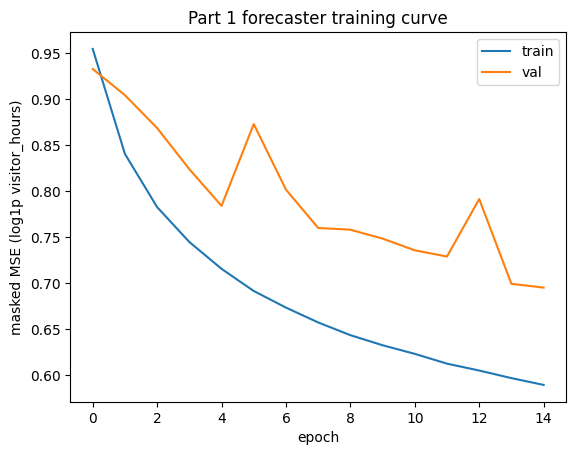

In [ ]:
"""Train and validate.

Train on clean-control train hours, validate on clean-control val hours.

Loss is masked MSE in log1p space over observed, non-venue node-hours.

`encode_nodes` is recomputed every mini-batch since its weights change each
step, but it's cheap: ~1.3k nodes and ~19k directed edges.
"""

BATCH_HOURS = 64
N_EPOCHS = 15
LR = 1e-3

optimizer = torch.optim.Adam(forecaster.parameters(), lr=LR, weight_decay=1e-5)
train_hour_ids = train_hour_mask.nonzero(as_tuple=True)[0].to(device)
val_hour_ids = val_hour_mask.nonzero(as_tuple=True)[0].to(device)
print(f"train hours: {len(train_hour_ids)}, val hours: {len(val_hour_ids)}")

def masked_mse(pred, target, mask):
	sq_err = (pred - target) ** 2 * mask
	return sq_err.sum() / mask.sum().clamp(min=1)

def run_epoch(hour_ids, train: bool):
	forecaster.train(train)
	order = hour_ids[torch.randperm(len(hour_ids))] if train else hour_ids
	total_loss, total_count = 0.0, 0
	for start in range(0, len(order), BATCH_HOURS):
		batch_hours = order[start:start + BATCH_HOURS]
		with torch.set_grad_enabled(train):
			node_embed = forecaster.encode_nodes(node_category_idx, node_static_x, edge_index, edge_weight)
			pred = forecaster(node_embed, hour_feat_x[batch_hours])
			y = log_target[batch_hours]
			mask = observed_mask[batch_hours] & node_loss_mask.unsqueeze(0)
			loss = masked_mse(pred, torch.nan_to_num(y), mask)
			if train:
				optimizer.zero_grad()
				loss.backward()
				optimizer.step()
		n_obs = mask.sum().item()
		total_loss += loss.item() * n_obs
		total_count += n_obs
	return total_loss / max(total_count, 1)

train_losses, val_losses = [], []
for epoch in range(N_EPOCHS):
	train_loss = run_epoch(train_hour_ids, train=True)
	val_loss = run_epoch(val_hour_ids, train=False)
	train_losses.append(train_loss)
	val_losses.append(val_loss)
	print(f"epoch {epoch + 1:02d}  train_mse={train_loss:.4f}  val_mse={val_loss:.4f}")

plt.title("Part 1 forecaster training curve")
plt.ylabel("masked MSE (log1p visitor_hours)")
plt.xlabel("epoch")
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.show()

In [17]:
"""Held-out evaluation on test x clean-control hours, reported in raw
visitor_hours units (undo the log1p transform)."""

@torch.no_grad()
def predict_hours(hour_ids):
	forecaster.eval()
	node_embed = forecaster.encode_nodes(node_category_idx, node_static_x, edge_index, edge_weight)
	preds = [
		forecaster(node_embed, hour_feat_x[hour_ids[start:start + BATCH_HOURS]])
		for start in range(0, len(hour_ids), BATCH_HOURS)
	]
	return torch.cat(preds, dim=0)  # (len(hour_ids), n_nodes), aligned with hour_ids order

test_hour_ids = test_hour_mask.nonzero(as_tuple=True)[0].to(device)
test_pred_log = predict_hours(test_hour_ids)
test_mask = observed_mask[test_hour_ids] & node_loss_mask.unsqueeze(0)

test_pred = torch.expm1(test_pred_log)
test_y = torch.expm1(torch.nan_to_num(log_target[test_hour_ids]))

mae = ((test_pred - test_y).abs() * test_mask).sum() / test_mask.sum()
rmse = (((test_pred - test_y) ** 2 * test_mask).sum() / test_mask.sum()).sqrt()
print(f"test MAE  (visitor_hours): {mae.item():.2f}")
print(f"test RMSE (visitor_hours): {rmse.item():.2f}")

test MAE  (visitor_hours): 84.28
test RMSE (visitor_hours): 183.58


## Part 2 — Generalization head

Run the trained forecaster on game-window hours to get `lift = observed - predicted` per node-hour, aggregate to a per-(date, ring) lift, then fit a small MLP that maps game-day covariates (attendance, first pitch hour, day/night, day-of-week, month) to that per-ring lift vector. 

This should answer our prediction regarding the possible lift of any future game.

In [19]:
"""Lift per node-hour on game-window hours. 

`relative_hour` is populated for every hour of every Giants home-game day (offset from first pitch)
allowing us to pick a window around first pitch (pregame arrival through postgame egress)
as the "game-impacted" hours rather than using the full day.
"""

LIFT_WINDOW = (-2, 4)  # hours relative to first pitch

game_hours_df = time_hour.filter(
	pl.col("giants_home") & pl.col("relative_hour").is_between(*LIFT_WINDOW)
).select(["hour_idx", "date"])
game_hour_ids = torch.tensor(game_hours_df["hour_idx"].to_numpy(), dtype=torch.long, device=device)
print(f"game-window hours: {len(game_hour_ids)} across {game_hours_df['date'].n_unique()} games")

game_pred = torch.expm1(predict_hours(game_hour_ids))
game_obs = torch.expm1(torch.nan_to_num(log_target[game_hour_ids]))
game_mask = (observed_mask[game_hour_ids] & node_loss_mask.unsqueeze(0)).cpu().numpy()
game_lift = (game_obs - game_pred).detach().cpu().numpy()  # (n_game_hours, n_nodes)

h_ids, n_ids = np.nonzero(game_mask)
dates_np = np.array(game_hours_df["date"].to_list())
lift_long = pl.DataFrame({
	"date": game_hours_df["date"].gather(h_ids),
	"node_idx": n_ids.astype(np.int64),
	"lift": game_lift[h_ids, n_ids],
})

node_ring_lookup = nodes.select(pl.col("node_idx").cast(pl.Int64), "ring_id", "ring")
ring_lift = (
	lift_long.join(node_ring_lookup, on="node_idx", how="left")
	.group_by(["date", "ring_id", "ring"])
	.agg(pl.col("lift").mean().alias("gnn_lift"), pl.len().alias("n_node_hours"))
	.sort(["date", "ring_id"])
)
print(f"date x ring rows: {ring_lift.height}")
ring_lift.head()

game-window hours: 1715 across 245 games
date x ring rows: 980


date,ring_id,ring,gnn_lift,n_node_hours
date,i32,str,f32,u32
2023-03-27,1,"""0-250m""",93.676643,22
2023-03-27,2,"""250-500m""",3.083667,65
2023-03-27,3,"""500m-1km""",48.055691,213
2023-03-27,4,"""1-2.5km""",55.362621,6074
2023-04-07,1,"""0-250m""",131.486603,23


In [ ]:
"""Build the Part 2 training set.

One row per game with covariates from `gnn_game_labels` (deduped across ring/measure, 
since those are the same per game date), and our GNN-derived per-ring lift as the target.

`split` is reused from `gnn_time_hour` so the game-level split matches the
forecaster's chronological split.
"""

game_cov = (
	game_labels.filter(pl.col("measure") == "visits")
	.select(["date", "attendance", "day_night", "first_pitch_hour", "dow"])
	.unique()
	.with_columns(pl.col("date").dt.month().alias("month"))
	.join(time_hour.select(["date", "split"]).unique(), on="date", how="left")
)

ring_lift_wide = ring_lift.pivot(values="gnn_lift", index="date", on="ring_id", aggregate_function="first")
ring_id_cols = [c for c in ring_lift_wide.columns if c != "date"]
ring_lift_wide = ring_lift_wide.rename({c: f"ring{c}_lift" for c in ring_id_cols})
ring_target_cols = sorted([c for c in ring_lift_wide.columns if c.endswith("_lift")])
ring_id_to_label = dict(node_ring_lookup.select(["ring_id", "ring"]).unique().iter_rows())

game_ds = game_cov.join(ring_lift_wide, on="date", how="inner").drop_nulls()
print(f"Part 2 dataset: {game_ds.height} games "
	  f"(dropped {game_cov.height - game_ds.height} without complete ring coverage)")
print(game_ds["split"].value_counts())

game_feat_df = game_ds.select(
	zscore(pl.col("attendance")).alias("attendance_z"),
	(pl.col("day_night") == "night").cast(pl.Float32).alias("is_night"),
	(TWO_PI * pl.col("first_pitch_hour") / 24).sin().alias("fp_sin"),
	(TWO_PI * pl.col("first_pitch_hour") / 24).cos().alias("fp_cos"),
	(TWO_PI * pl.col("dow") / 7).sin().alias("dow_sin"),
	(TWO_PI * pl.col("dow") / 7).cos().alias("dow_cos"),
	(TWO_PI * pl.col("month") / 12).sin().alias("month_sin"),
	(TWO_PI * pl.col("month") / 12).cos().alias("month_cos"),
)
game_X = torch.tensor(game_feat_df.to_numpy(), dtype=torch.float32)
game_Y = torch.tensor(game_ds.select(ring_target_cols).to_numpy(), dtype=torch.float32)

game_split_arr = game_ds["split"].to_numpy()
game_train_mask = torch.tensor(game_split_arr == "train")
game_val_mask = torch.tensor(game_split_arr == "val")
game_test_mask = torch.tensor(game_split_arr == "test")
print("game feature dims:", game_X.shape, "target dims:", game_Y.shape)

Part 2 dataset: 245 games (dropped 1 without complete ring coverage)
shape: (3, 2)
┌───────┬───────┐
│ split ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ test  ┆ 39    │
│ val   ┆ 44    │
│ train ┆ 162   │
└───────┴───────┘
game feature dims: torch.Size([245, 8]) target dims: torch.Size([245, 4])


epoch 050  train_mse=2956.16  val_mse=1220.09
epoch 100  train_mse=2781.00  val_mse=1143.29
epoch 150  train_mse=2252.99  val_mse=950.98
epoch 200  train_mse=1398.49  val_mse=786.32
epoch 250  train_mse=809.57  val_mse=920.93
epoch 300  train_mse=616.57  val_mse=1067.26


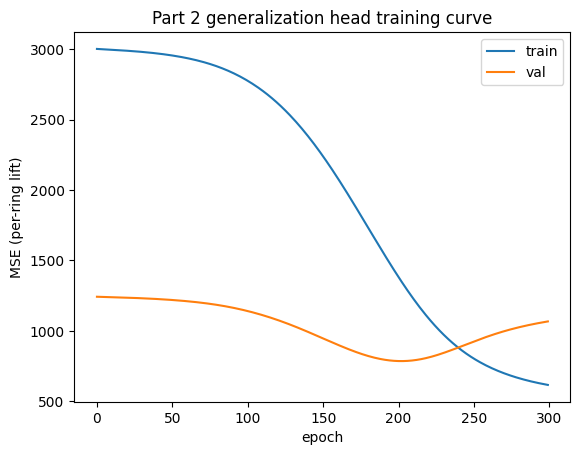

In [ ]:
"""Generalization head: small MLP mapping game covariates to a vector of per-ring lift predictions."""

class LiftGeneralizationHead(nn.Module):
	def __init__(self, in_dim, n_rings, hidden_dim=16):
		super().__init__()
		self.net = nn.Sequential(
			nn.Linear(in_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, n_rings),
		)

	def forward(self, x):
		return self.net(x)

gen_head = LiftGeneralizationHead(in_dim=game_X.shape[1], n_rings=game_Y.shape[1])
optimizer2 = torch.optim.Adam(gen_head.parameters(), lr=1e-3, weight_decay=1e-3)

N_EPOCHS_2 = 300
X_train, Y_train = game_X[game_train_mask], game_Y[game_train_mask]
X_val, Y_val = game_X[game_val_mask], game_Y[game_val_mask]

train_losses2, val_losses2 = [], []
for epoch in range(N_EPOCHS_2):
	gen_head.train()
	pred = gen_head(X_train)
	loss = F.mse_loss(pred, Y_train)
	optimizer2.zero_grad()
	loss.backward()
	optimizer2.step()

	gen_head.eval()
	with torch.no_grad():
		val_loss = F.mse_loss(gen_head(X_val), Y_val)
	train_losses2.append(loss.item())
	val_losses2.append(val_loss.item())
	if (epoch + 1) % 50 == 0:
		print(f"epoch {epoch + 1:03d}  train_mse={loss.item():.2f}  val_mse={val_loss.item():.2f}")

plt.title("Part 2 generalization head training curve")
plt.ylabel("MSE (per-ring lift)")
plt.xlabel("epoch")
plt.plot(train_losses2, label="train")
plt.plot(val_losses2, label="val")
plt.legend()
plt.show()

    0-250m: test MAE = 40.17
  250-500m: test MAE = 36.12
  500m-1km: test MAE = 22.19
   1-2.5km: test MAE = 18.58


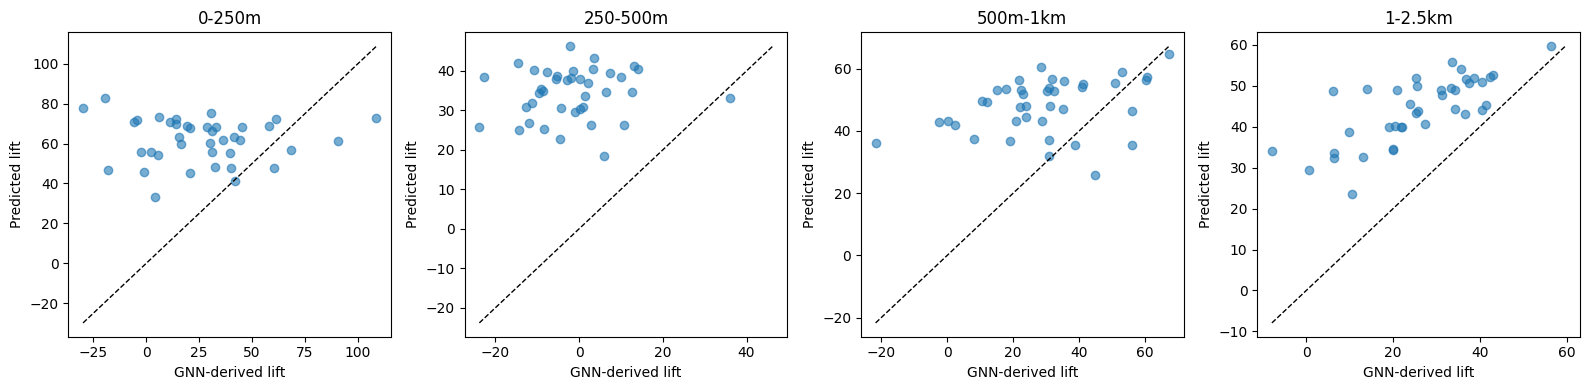

In [31]:
"""Held-out evaluation: per-ring MAE plus predicted-vs-GNN-derived lift
scatter, one panel per ring, on the test-split games."""

gen_head.eval()
with torch.no_grad():
	test_pred = gen_head(game_X[game_test_mask]).numpy()
test_true = game_Y[game_test_mask].numpy()

ring_labels = [ring_id_to_label[int(c.replace("ring", "").replace("_lift", ""))] for c in ring_target_cols]
for name, col in zip(ring_labels, range(len(ring_target_cols))):
	mae_r = np.abs(test_pred[:, col] - test_true[:, col]).mean()
	print(f"{name:>10}: test MAE = {mae_r:.2f}")

fig, axes = plt.subplots(1, len(ring_labels), figsize=(4 * len(ring_labels), 4))
for ax, name, col in zip(axes, ring_labels, range(len(ring_target_cols))):
	ax.set_title(name)
	ax.set_ylabel("Predicted lift")
	ax.set_xlabel("GNN-derived lift")
	ax.scatter(test_true[:, col], test_pred[:, col], alpha=0.6)
	lo = min(test_true[:, col].min(), test_pred[:, col].min())
	hi = max(test_true[:, col].max(), test_pred[:, col].max())
	ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
	
plt.tight_layout()
plt.show()